In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
rain_df = pd.read_csv("Rainfall_1901_2016_PAK.csv")
rain_df.head()

,Rainfall - (MM),Year,Month
0,40.4258,1901,January
1,12.3022,1901,February
2,25.5119,1901,March
3,14.2942,1901,April
4,38.3046,1901,May


In [15]:
print(rain_df.columns)

Index(['Rainfall - (MM)', ' Year', 'Month'], dtype='object')


In [ ]:
rain_df = rain_df[[' Year', 'Rainfall - (MM)']]
rain_df = rain_df.dropna()

In [19]:
yearly_rain = rain_df.groupby(' Year')['Rainfall - (MM)'].sum()

In [20]:
yearly_rain = yearly_rain[yearly_rain.index >= 1970]
print(yearly_rain.head())

 Year
1970    309.28040
1971    204.34619
1972    275.08196
1973    317.57482
1974    213.32067
Name: Rainfall - (MM), dtype: float64


In [21]:
rolling_rain = yearly_rain.rolling(window=5).mean()


In [22]:
x = yearly_rain.index
y = yearly_rain.values

z = np.polyfit(x, y, 1)
trend_line = np.poly1d(z)

In [23]:
max_rain_year = yearly_rain.idxmax()
max_rain_value = yearly_rain.max()

min_rain_year = yearly_rain.idxmin()
min_rain_value = yearly_rain.min()

print("Highest Rainfall Year:", max_rain_year)
print("Lowest Rainfall Year:", min_rain_year)

Highest Rainfall Year: 1994
Lowest Rainfall Year: 2000


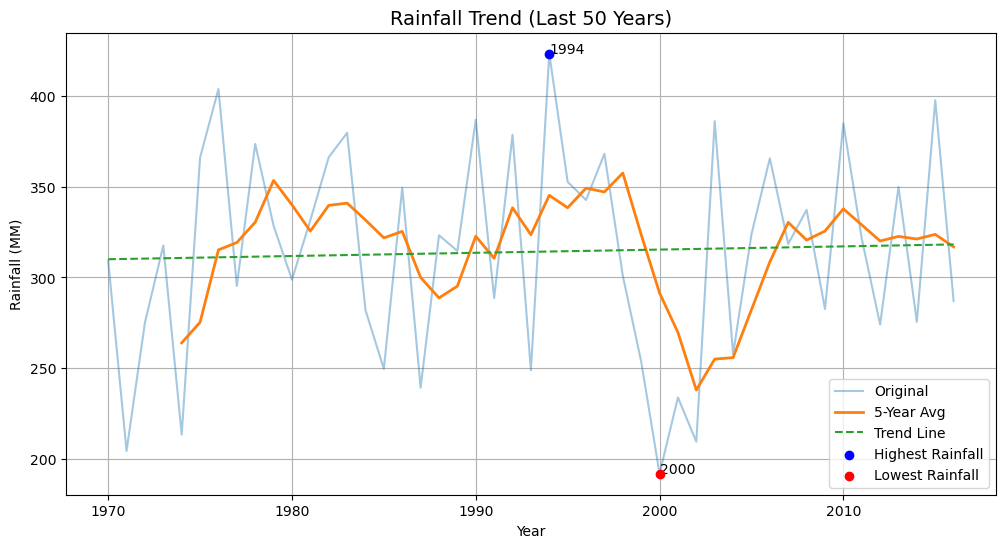

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(yearly_rain.index, yearly_rain.values, label='Original', alpha=0.4)
plt.plot(rolling_rain.index, rolling_rain.values, label='5-Year Avg', linewidth=2)
plt.plot(x, trend_line(x), label='Trend Line', linestyle='--')

# Highest rainfall
plt.scatter(max_rain_year, max_rain_value, color='blue', label='Highest Rainfall', zorder=5)
plt.text(max_rain_year, max_rain_value, f"{max_rain_year}", fontsize=10)

# Lowest rainfall (drought sookha pan)
plt.scatter(min_rain_year, min_rain_value, color='red', label='Lowest Rainfall', zorder=5)
plt.text(min_rain_year, min_rain_value, f"{min_rain_year}", fontsize=10)

plt.title("Rainfall Trend (Last 50 Years)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Rainfall (MM)")
plt.legend()

plt.grid(True)

plt.show()

In [26]:
# Measure rainfall variability (instability)
rain_variability = yearly_rain.rolling(window=5).std()

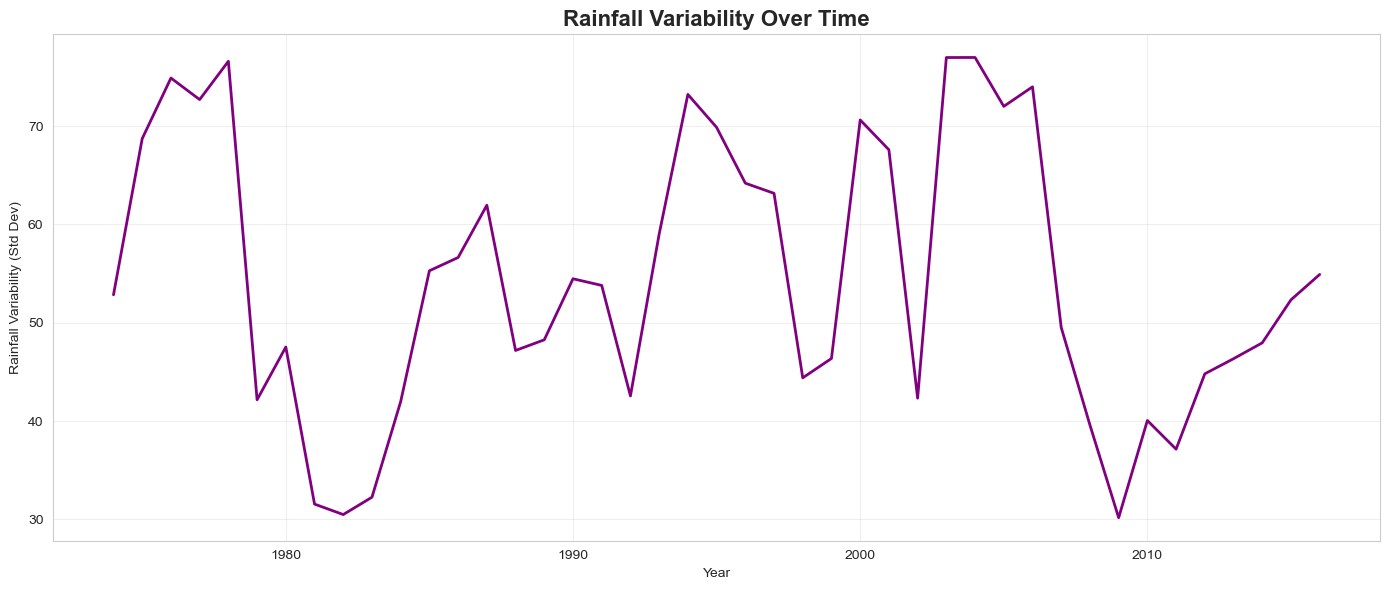

In [ ]:
plt.figure(figsize=(14,6))

sns.set_style("whitegrid")

plt.plot(
    rain_variability.index,
    rain_variability.values,
    color='purple',
    linewidth=2
)

plt.title(
    "Rainfall Variability Over Time",
    fontsize=16,
    fontweight='bold'
)
plt.xlabel("Year")
plt.ylabel("Rainfall Variability (Std Dev)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [29]:
# Convert years into decades
decade_rain = yearly_rain.groupby((yearly_rain.index // 10) * 10).mean()

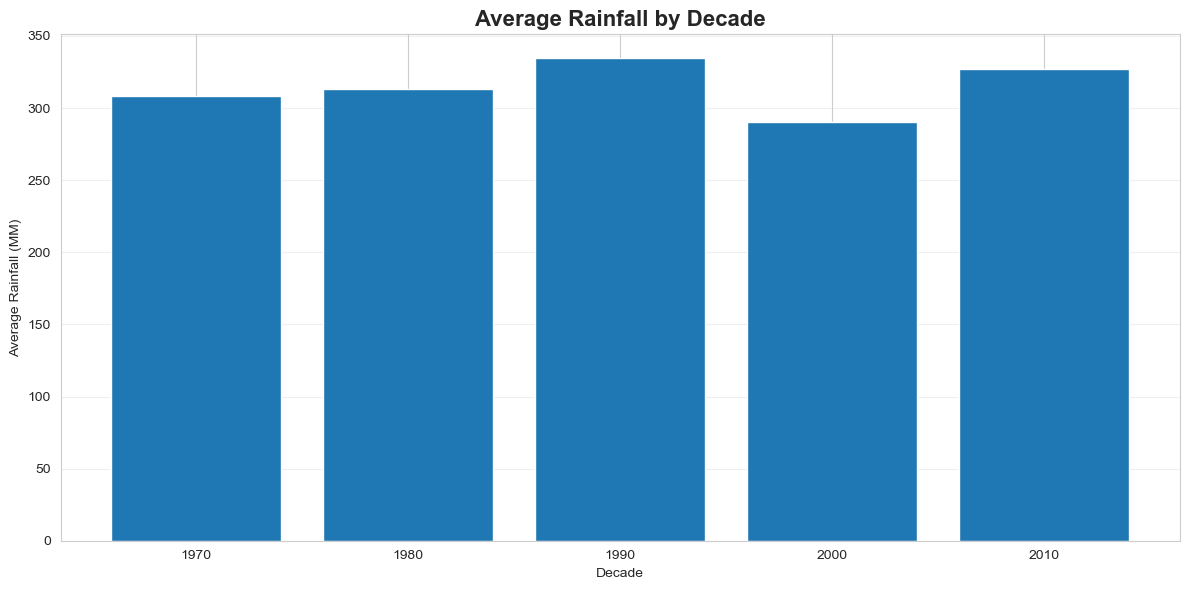

In [ ]:
plt.figure(figsize=(12,6))

sns.set_style("whitegrid")
plt.bar(
    decade_rain.index.astype(str),
    decade_rain.values
)

plt.title(
    "Average Rainfall by Decade",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Decade")
plt.ylabel("Average Rainfall (MM)")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


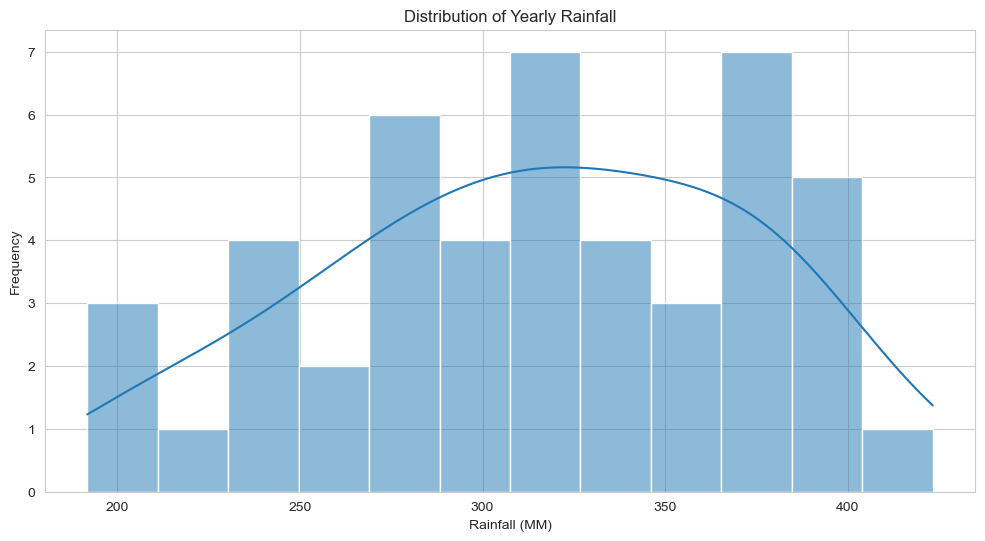

In [37]:
plt.figure(figsize=(12,6))

sns.set_style("whitegrid")

sns.histplot(
    yearly_rain.values,
    bins=12,
    kde=True
)

plt.title("Distribution of Yearly Rainfall")

plt.xlabel("Rainfall (MM)")
plt.ylabel("Frequency")

plt.show()

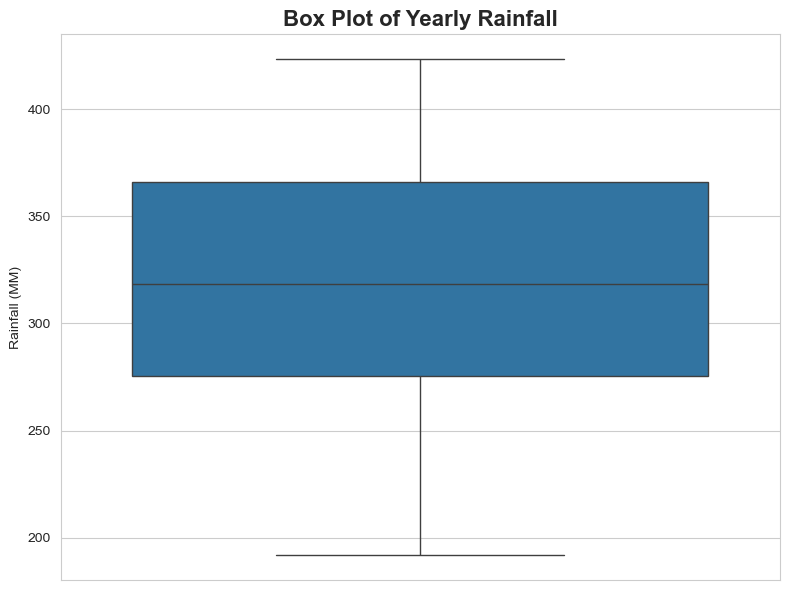

In [38]:
plt.figure(figsize=(8,6))

sns.set_style("whitegrid")

sns.boxplot(
    y=yearly_rain.values
)

plt.title(
    "Box Plot of Yearly Rainfall",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Rainfall (MM)")

plt.tight_layout()

plt.show()

### Rainfall Trend Analysis

- The rainfall trend shows fluctuations over the years.
- The rolling average highlights long-term rainfall patterns.
- The highest rainfall year indicates extreme weather conditions.
- The lowest rainfall year may indicate drought conditions.
- These variations suggest climate instability over time.